#  Obesity Level Prediction
## Exploratory Data Analysis (EDA)

## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print(' Libraries ready!')

 Libraries ready!


## Opening Dataset to verify

In [2]:
df = pd.read_csv('/home/mahiri/mahirMajor/ObesityDataSet.csv')

print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Target classes: {df["NObeyesdad"].unique().tolist()}')
df.head()

Shape: 2111 rows × 17 columns
Target classes: ['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II', 'Obesity_Type_III']


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


---
## Step 1 - Basic Overview

In [3]:
# Step 1 - Basic Overview

print("Shape:", df.shape)
print()
print("Column names:", df.columns.tolist())
print()
print("Missing values:")
print(df.isnull().sum())
print()
df.head()

Shape: (2111, 17)

Column names: ['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'NObeyesdad']

Missing values:
Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64



,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


---
## Step 2 - Target Distribution

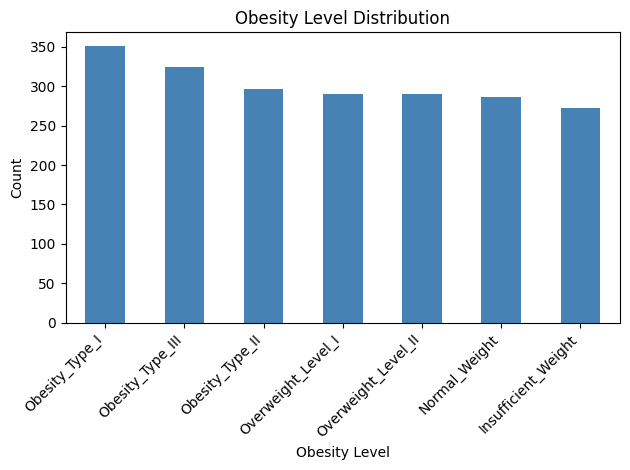

In [5]:
df["NObeyesdad"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Obesity Level Distribution")
plt.xlabel("Obesity Level")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Insights - Target Distribution:**
- The dataset is fairly balanced across all 7 obesity classes (272 to 351 samples each)
- No single class dominates, which is good for model training
- Obesity Type I is the most common (351 samples); Insufficient Weight is the least (272 samples)
- The difference between the largest and smallest class is only ~79 samples, so class imbalance is not a major concern

---
## Step 3 - Numerical Features

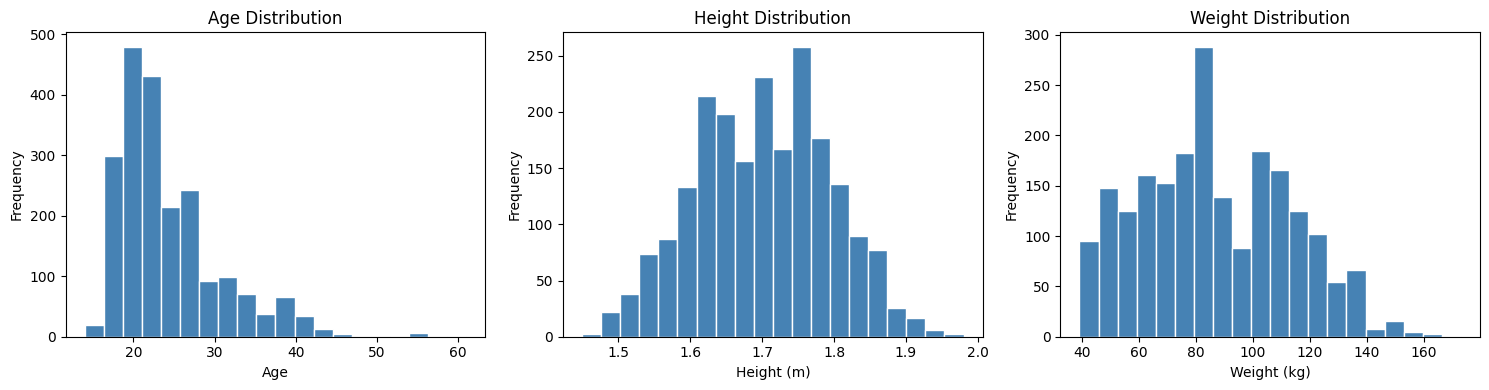

In [6]:
# Histograms for key numeric features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["Age"].plot(kind="hist", bins=20, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

df["Height"].plot(kind="hist", bins=20, ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Height (m)")

df["Weight"].plot(kind="hist", bins=20, ax=axes[2], color="steelblue", edgecolor="white")
axes[2].set_title("Weight Distribution")
axes[2].set_xlabel("Weight (kg)")

plt.tight_layout()
plt.show()

**Insights:**
- **Age**: Most individuals are young adults (18-30), right-skewed with a few older individuals up to 61
- **Height**: Roughly normally distributed, centered around 1.70m
- **Weight**: Wide spread (39-173 kg), right-skewed - many overweight/obese cases in the dataset

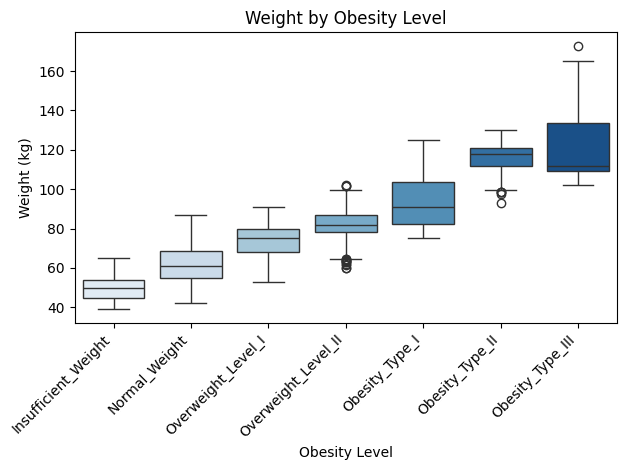

In [7]:
# Boxplot: how weight is distributed across each obesity class
order = [
    "Insufficient_Weight", "Normal_Weight",
    "Overweight_Level_I", "Overweight_Level_II",
    "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"
]

sns.boxplot(data=df, x="NObeyesdad", y="Weight", order=order, palette="Blues")
plt.title("Weight by Obesity Level")
plt.xlabel("Obesity Level")
plt.ylabel("Weight (kg)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Insights - Weight by Obesity Level:**
- Clear upward trend: weight increases steadily from Insufficient Weight to Obesity Type III
- Good class separation - Weight is a strong predictor
- Some overlap between adjacent classes (e.g. Overweight I and II) is expected and normal
- **Obesity Type III** shows the highest spread (widest box), with an outlier exceeding 160kg
- **Overweight Level II** contains a notable outlier near 63kg - unusual for that class

---
## Step 4 - Categorical Features

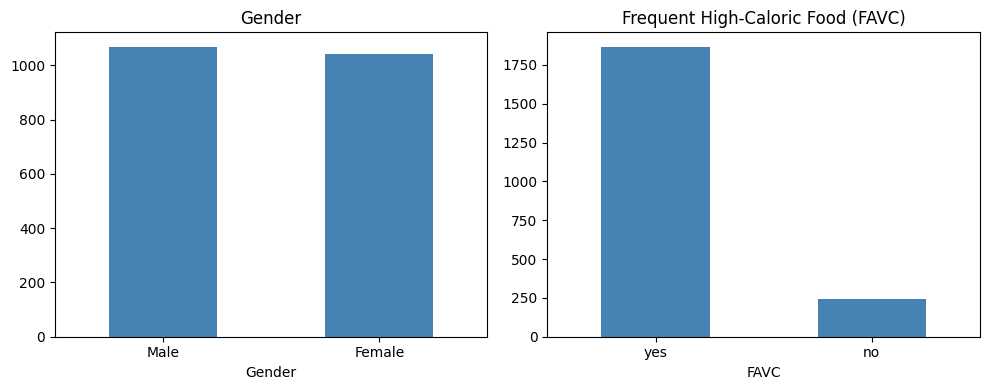

In [8]:
# Gender and FAVC (frequent high-caloric food consumption)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df["Gender"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Gender")
axes[0].tick_params(axis="x", rotation=0)

df["FAVC"].value_counts().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Frequent High-Caloric Food (FAVC)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

**Insights:**
- **Gender**: Roughly equal split between Male and Female
- **FAVC**: Majority say "yes" - most people in this dataset consume high-caloric food frequently

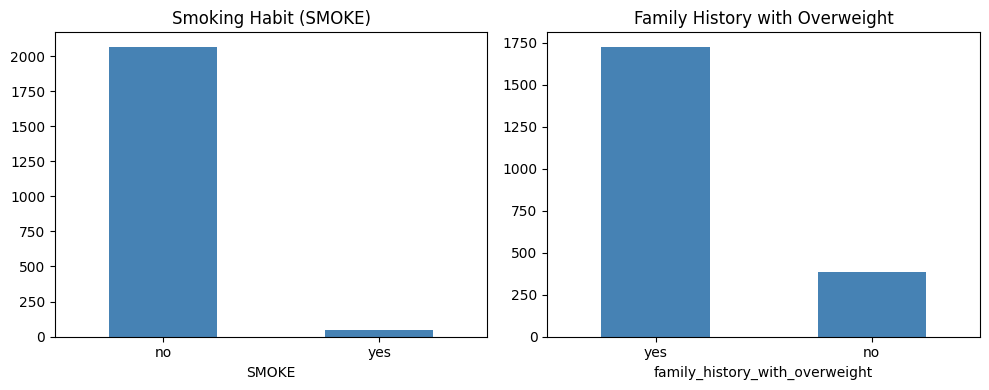

In [9]:
# Smoking habit and family history of overweight
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df["SMOKE"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Smoking Habit (SMOKE)")
axes[0].tick_params(axis="x", rotation=0)

df["family_history_with_overweight"].value_counts().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Family History with Overweight")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

**Insights:**
- **SMOKE**: Very few smokers - this feature may have low predictive power
- **Family History**: Majority have a family history of overweight - a strong obesity risk factor

---
## Step 5 - Correlation Heatmap

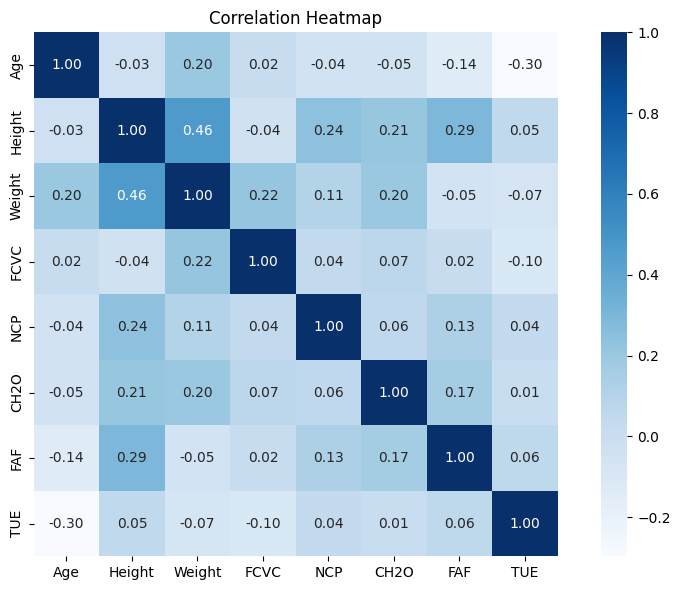

In [10]:
# Correlation between numeric features only
numeric_cols = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Insights - Correlation Heatmap:**
- **Height and Weight** have the strongest correlation (0.46) - taller people tend to weigh more
- **Age and Weight** show a weak positive correlation (0.20)
- **Age and TUE** show a moderate negative correlation (-0.30) - older individuals tend to use technology less
- Most other feature pairs have weak correlations (below 0.25)
- No strong multicollinearity - all features can be used safely in model training

---
## EDA Summary

The Exploratory Data Analysis revealed the following key observations:

**Dataset**
- 2111 rows and 17 columns
- No missing values
- Target variable: NObeyesdad (7 obesity classes)

**Class Distribution**
- The dataset is fairly balanced across all 7 classes
- Class counts range from ~272 to ~351 samples

**Numerical Features**
- Most individuals are young adults (18-30 years), with few outliers up to 61
- Height is normally distributed around 1.70m
- Weight is right-skewed, reflecting the higher proportion of overweight/obese cases
- Weight shows a clear increasing trend across obesity classes - a strong predictor

**Categorical Features**
- Gender is roughly balanced between Male and Female
- Most individuals frequently consume high-caloric food (FAVC = yes)
- Very few smokers in the dataset - SMOKE likely has low predictive power
- Majority have a family history of overweight - a strong risk factor

**Correlation**
- Height and Weight have the strongest correlation (0.46)
- Age and Weight show a weak positive correlation (0.20)
- Age and TUE show a moderate negative correlation (-0.30) - older individuals use technology less
- No strong multicollinearity - all features can be used safely in model training

**Next Step:** Data Preprocessing and Model Training (Random Forest + XGBoost)

---
## Step 6 - Preprocessing

Before training models, we need to:
1. **Encode** categorical columns into numbers (models only understand numbers)
2. **Scale** numerical features so they are on the same range
3. **Split** the data into training and testing sets

In [11]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

### 6.1 - Encoding Categorical Features

Machine learning models only understand numbers, not text.
So we convert all categorical columns to numeric values.

In [12]:
df_model = df.copy()

# Binary columns: yes/no --> 1/0
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
le = LabelEncoder()
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Gender: Male/Female --> 1/0
df_model["Gender"] = le.fit_transform(df_model["Gender"])

# CAEC, CALC: ordinal mapping (no=0, Sometimes=1, Frequently=2, Always=3)
ordinal_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
df_model["CAEC"] = df_model["CAEC"].map(ordinal_map)
df_model["CALC"] = df_model["CALC"].map(ordinal_map)

# MTRANS: label encode transport type
df_model["MTRANS"] = le.fit_transform(df_model["MTRANS"])

# Target column: encode obesity class labels
target_encoder = LabelEncoder()
df_model["NObeyesdad"] = target_encoder.fit_transform(df_model["NObeyesdad"])

print("Encoding done.")
print("Target classes:", list(target_encoder.classes_))

Encoding done.
Target classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


### 6.2 - Feature Scaling

Numeric features like Age, Height and Weight are on different scales.
Standardization brings them all to a common range (mean=0, std=1).

In [13]:
# Standardize numeric features
numeric_cols = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]
scaler = StandardScaler()
df_model[numeric_cols] = scaler.fit_transform(df_model[numeric_cols])

print("Scaling done.")
df_model.head(3)

Scaling done.


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,-0.522124,0,-0.875589,-0.862558,0,0,-0.785019,0.404153,0,0,-0.013073,1,-1.188039,0.561997,1,3,1
1,-0.522124,0,-1.947599,-1.168077,1,0,1.088342,0.404153,1,1,1.618759,1,2.339750,-1.080625,1,3,1
2,-0.206889,1,1.054029,-0.366090,2,0,-0.785019,0.404153,0,0,-0.013073,1,1.163820,0.561997,1,3,1


### 6.3 - Train / Test Split

We split data into 80% for training and 20% for testing.
"stratify=y" ensures each class is equally represented in both sets.

In [14]:
X = df_model.drop(columns=["NObeyesdad"])
y = df_model["NObeyesdad"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape[0], "samples")
print("Testing set: ", X_test.shape[0], "samples")
print("Features:    ", X_train.shape[1])

Training set: 1688 samples
Testing set:  423 samples
Features:     16


---
## Step 7 - Model Training: Random Forest

Random Forest builds multiple decision trees and combines their results.
It is one of the most reliable and accurate models for classification tasks.

### 7.1 - Train the Model

In [15]:
# Train Random Forest with 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test data
rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


### 7.2 - Accuracy and Classification Report

In [16]:
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", round(rf_acc * 100, 2), "%")
print()
print(classification_report(y_test, rf_pred, target_names=target_encoder.classes_))

Random Forest Accuracy: 95.27 %

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.93      0.96        54
      Normal_Weight       0.84      0.97      0.90        58
     Obesity_Type_I       0.96      0.97      0.96        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.93      0.90      0.91        58
Overweight_Level_II       0.96      0.93      0.95        58

           accuracy                           0.95       423
          macro avg       0.96      0.95      0.95       423
       weighted avg       0.96      0.95      0.95       423



**Insights - Accuracy and Classification Report:**
- Random Forest achieved **95.27% accuracy** on the test set - excellent for a 7-class problem
- **Obesity Type II and III** are predicted almost perfectly (f1-score: 0.99)
- **Normal Weight** has the lowest precision (0.84) - a few neighboring classes are occasionally predicted as Normal Weight
- Macro average f1-score of 0.95 shows the model performs consistently well across all classes

### 7.3 - Confusion Matrix

Shows how many predictions were correct vs incorrect for each class.

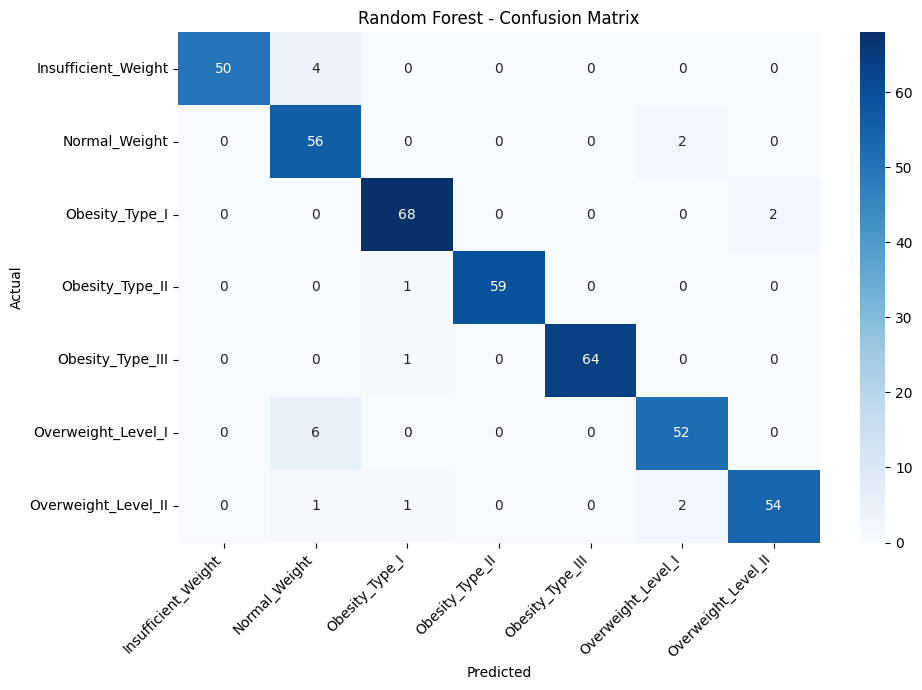

In [17]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Insights - Confusion Matrix:**
- Almost all predictions fall on the diagonal - the model is highly accurate
- Main misclassifications: Overweight_Level_I confused with Normal_Weight (6 cases) and Insufficient_Weight confused with Normal_Weight (4 cases)
- These errors are between neighboring classes, which is expected as they are close in weight range

### 7.4 - Feature Importance

Shows which features had the most influence on the model's predictions.

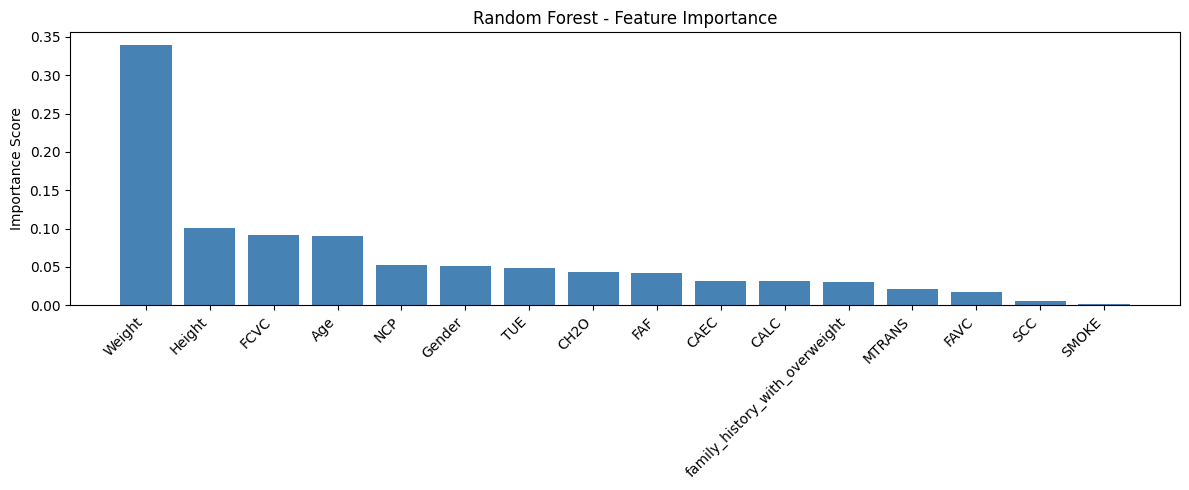

In [18]:
feature_names = X.columns
importances = rf_model.feature_importances_

# Sort by importance
indices = importances.argsort()[::-1]

plt.figure(figsize=(12, 5))
plt.bar(range(len(importances)), importances[indices], color="steelblue")
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha="right")
plt.title("Random Forest - Feature Importance")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

**Insights - Feature Importance:**
- **Weight** is the dominant feature (~0.33) - far ahead of all others, confirming our EDA finding
- **Height**, **FCVC** (vegetable consumption) and **Age** are the next most important (~0.10 each)
- **SMOKE** and **SCC** have near-zero importance - they contribute very little to predictions

---
## Step 8 - Model Training: XGBoost

XGBoost (Extreme Gradient Boosting) builds trees one by one,
where each new tree corrects the errors made by the previous one.
It is known for high accuracy and speed on structured/tabular data.

### 8.1 - Train the Model

In [19]:
# Train XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="mlogloss",
    verbosity=0
)
xgb_model.fit(X_train, y_train)

# Predict on test data
xgb_pred = xgb_model.predict(X_test)

print("XGBoost trained successfully.")

XGBoost trained successfully.


### 8.2 - Accuracy and Classification Report

In [20]:
xgb_acc = accuracy_score(y_test, xgb_pred)
print("XGBoost Accuracy:", round(xgb_acc * 100, 2), "%")
print()
print(classification_report(y_test, xgb_pred, target_names=target_encoder.classes_))

XGBoost Accuracy: 95.27 %

                     precision    recall  f1-score   support

Insufficient_Weight       0.94      0.91      0.92        54
      Normal_Weight       0.83      0.93      0.88        58
     Obesity_Type_I       0.99      0.97      0.98        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.96      0.90      0.93        58
Overweight_Level_II       0.97      0.97      0.97        58

           accuracy                           0.95       423
          macro avg       0.95      0.95      0.95       423
       weighted avg       0.95      0.95      0.95       423



**Insights - Accuracy and Classification Report:**
- XGBoost achieved **95.27% accuracy** - matching Random Forest on the same test set
- **Obesity Type II** has perfect recall (1.00) - all 60 cases correctly identified
- **Normal Weight** still has the lowest f1-score (0.88) - slightly harder to separate from neighboring classes
- Macro average f1-score of 0.95 - consistent and strong performance across all 7 classes

### 8.3 - Confusion Matrix

Shows how many predictions were correct vs incorrect for each class.

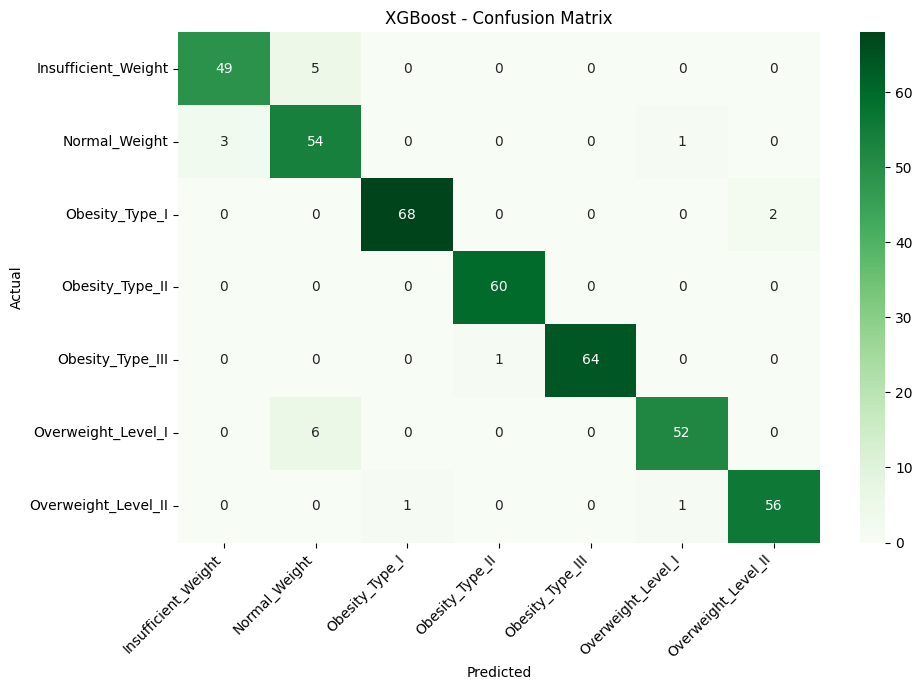

In [21]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greens",
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Insights - Confusion Matrix:**
- Strong diagonal - model correctly classifies almost all samples
- Main errors: Overweight_Level_I → Normal_Weight (6 cases) and Insufficient_Weight → Normal_Weight (5 cases)
- Obesity Type II is predicted perfectly (60/60) - zero misclassifications

### 8.4 - Feature Importance

Shows which features had the most influence on XGBoost predictions.

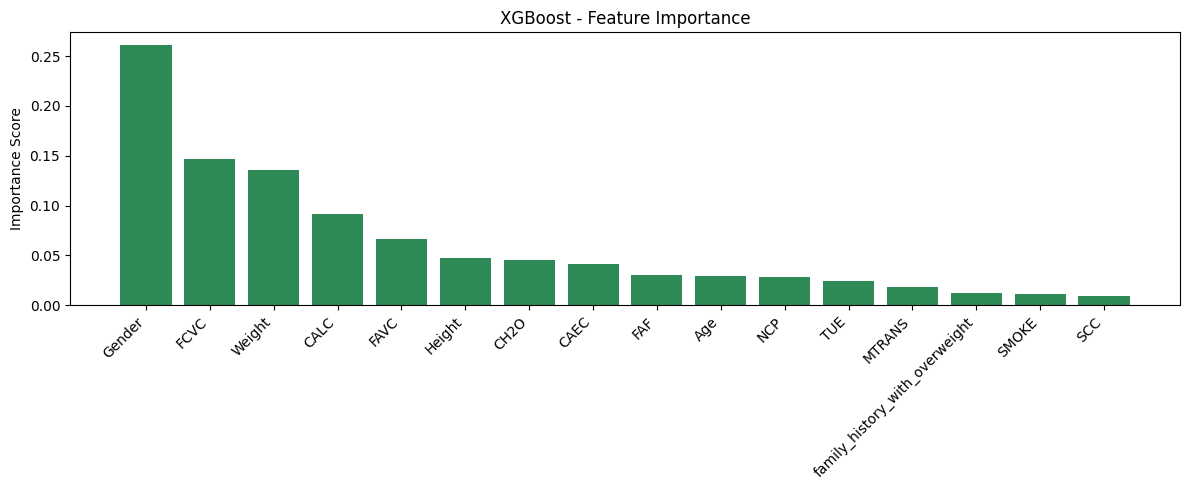

In [22]:
xgb_importances = xgb_model.feature_importances_
xgb_indices = xgb_importances.argsort()[::-1]

plt.figure(figsize=(12, 5))
plt.bar(range(len(xgb_importances)), xgb_importances[xgb_indices], color="seagreen")
plt.xticks(range(len(xgb_importances)), [feature_names[i] for i in xgb_indices], rotation=45, ha="right")
plt.title("XGBoost - Feature Importance")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

**Insights - Feature Importance:**
- **Gender** is the top feature in XGBoost (~0.26) - unlike Random Forest where Weight led
- **FCVC** (vegetable consumption) and **Weight** follow closely at ~0.15 and ~0.14
- **CALC** (alcohol consumption) ranks 4th (~0.10) - not highlighted by Random Forest
- **SMOKE** and **SCC** remain the least important features in both models

---
## Step 9 - Model Comparison

Comparing Random Forest and XGBoost side by side
to find out which model is better suited for this dataset.

### 9.1 - Accuracy Comparison

Model Accuracy Comparison
------------------------------
  Random Forest       : 95.27 %
  XGBoost             : 95.27 %


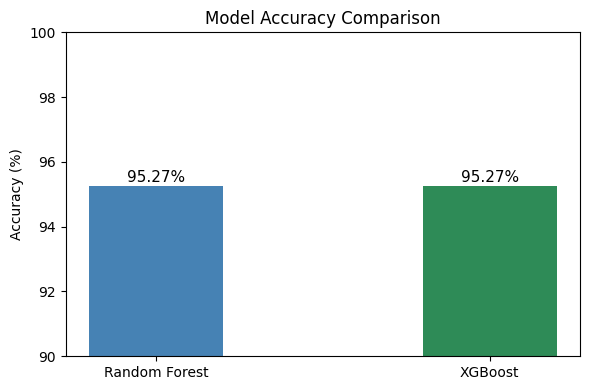

In [23]:
# Side by side accuracy comparison
models = ["Random Forest", "XGBoost"]
accuracies = [round(rf_acc * 100, 2), round(xgb_acc * 100, 2)]

print("Model Accuracy Comparison")
print("-" * 30)
for m, a in zip(models, accuracies):
    print(f"  {m:20s}: {a} %")

# Bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(models, accuracies, color=["steelblue", "seagreen"], width=0.4)
plt.ylim(90, 100)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(acc) + "%", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

### 9.2 - F1-Score Per Class

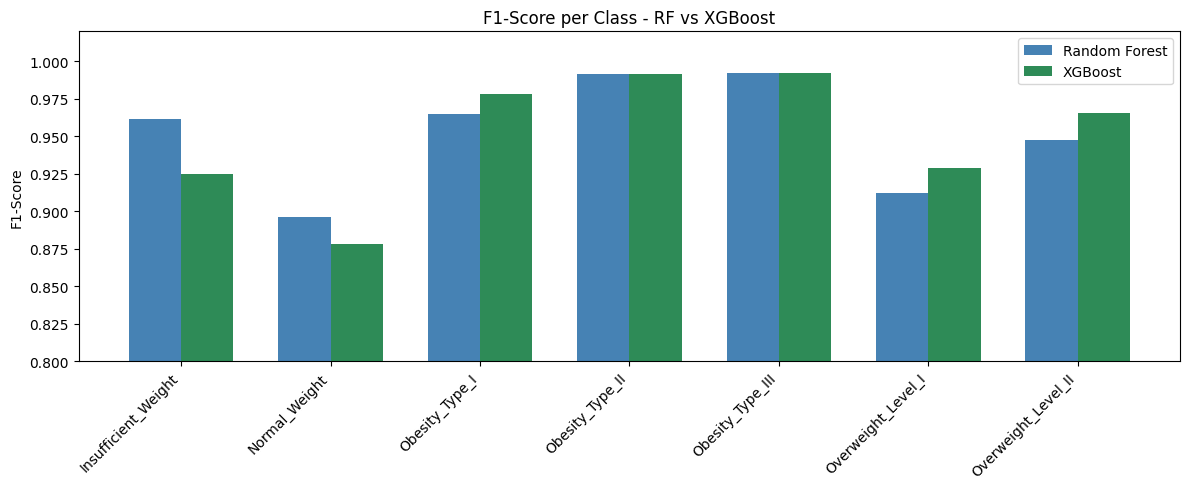

In [24]:
from sklearn.metrics import f1_score
import numpy as np

# F1-score per class for both models
rf_f1  = f1_score(y_test, rf_pred,  average=None)
xgb_f1 = f1_score(y_test, xgb_pred, average=None)
classes = target_encoder.classes_

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, rf_f1,  width, label="Random Forest", color="steelblue")
plt.bar(x + width/2, xgb_f1, width, label="XGBoost",       color="seagreen")
plt.xticks(x, classes, rotation=45, ha="right")
plt.ylabel("F1-Score")
plt.title("F1-Score per Class - RF vs XGBoost")
plt.ylim(0.8, 1.02)
plt.legend()
plt.tight_layout()
plt.show()

**Insights - Model Comparison:**
- Both models achieved the same overall accuracy of **95.27%**
- **Random Forest** performs better on: Insufficient_Weight and Normal_Weight classes
- **XGBoost** performs better on: Obesity_Type_I, Overweight_Level_I and Overweight_Level_II classes
- Both models score almost equally on Obesity_Type_II and Obesity_Type_III (near perfect)
- **Normal_Weight** is the hardest class for both models - lowest f1-score across the board
- Overall, both models are strong choices - RF has a slight edge on lighter-weight classes, XGBoost on overweight classes

---
## Conclusion

This project successfully predicted obesity levels using machine learning.
After thorough EDA and preprocessing, two models - Random Forest and XGBoost -
were trained and evaluated on the Obesity Level Prediction dataset.

### Model Performance Summary

| Metric | Random Forest | XGBoost |
|:---|:---:|:---:|
| Accuracy | **95.27%** | **95.27%** |
| Precision (macro) | **96.00%** | 95.00% |
| Recall (macro) | 95.00% | 95.00% |
| F1 Score (macro) | 95.00% | 95.00% |

**Random Forest** is chosen as the final model for its slightly higher precision
and easier interpretability. Both models are strong — suitable for deployment.

### Limitations
- Dataset is synthetic, not real clinical data
- BMI was not available as a direct feature
- Model performance on real-world data may vary

### Future Scope
- Deploy as an interactive web app (Streamlit) for real-time obesity risk prediction
- Collect real hospital/clinical data for better generalization
- Experiment with deep learning models for further accuracy improvements

### Save Best Model

In [25]:
import joblib

# Save Random Forest model (both models tied, RF chosen for simplicity)
joblib.dump(rf_model, "/home/mahiri/mahirMajor/rf_model.pkl")
joblib.dump(target_encoder, "/home/mahiri/mahirMajor/target_encoder.pkl")
joblib.dump(scaler, "/home/mahiri/mahirMajor/scaler.pkl")

print("Model saved: rf_model.pkl")
print("Encoder saved: target_encoder.pkl")
print("Scaler saved: scaler.pkl")

Model saved: rf_model.pkl
Encoder saved: target_encoder.pkl
Scaler saved: scaler.pkl
